# Step 3.2 — Outlier Detection

**Goal:** Identify laws that are semantically isolated — documents so different from the rest of the corpus that they would destabilize clustering rather than inform it.

**Why before clustering?**  
K-Means is sensitive to outliers: a single extreme document can pull a centroid away from a genuine cluster. DBSCAN labels outliers as noise (label -1) automatically, but their presence still affects the density estimation. Identifying outliers beforehand gives us a conscious, documented decision — keep or exclude — rather than letting them silently distort results.

**Method: Isolation Forest**  
Isolation Forest detects anomalies by randomly partitioning the feature space. Points that require fewer splits to isolate are more anomalous. It handles high-dimensional data well (TF-IDF: 5000 features) and makes no assumptions about the shape of the normal distribution.

We run it on **both** scaled matrices and cross-check with a simple **token-count filter** — very short documents are likely outliers by construction (too little text to generate a meaningful vector).

## 1. Setup

In [1]:
import numpy as np
import scipy.sparse as sp
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import os

CLEAN_DATA_PATH   = "../data/processed/sgbs_clean.csv"
TFIDF_SCALED_PATH = "../data/processed/tfidf_scaled.npz"
W2V_SCALED_PATH   = "../data/processed/word2vec_scaled.npy"
OUTLIER_FLAG_PATH = "../data/processed/outlier_flags.csv"

df        = pd.read_csv(CLEAN_DATA_PATH)
X_tfidf   = sp.load_npz(TFIDF_SCALED_PATH).tocsr()
X_w2v     = np.load(W2V_SCALED_PATH)

print(f"Documents:       {len(df)}")
print(f"TF-IDF matrix:   {X_tfidf.shape}")
print(f"Word2Vec matrix: {X_w2v.shape}")

Documents:       733
TF-IDF matrix:   (733, 5000)
Word2Vec matrix: (733, 100)


## 2. Token-Count Filter

Documents with very few tokens after all cleaning steps have too little semantic content to be clustered meaningfully. We flag documents below a minimum threshold.

Token count — min: 5, median: 227, max: 8912


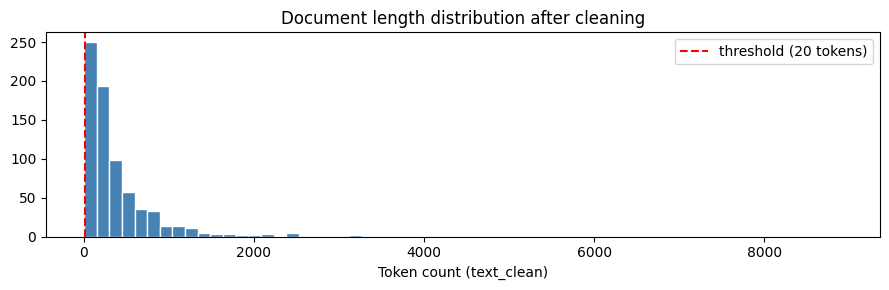


Documents with < 20 tokens: 9
                                                                                                                                                   title_de systematic_number  token_count
38                                                                                                                                       Denkmalverzeichnis           497.300           11
147                                                                                      Verordnung über den Vollzug der eidgenössischen Waffengesetzgebung           568.200           17
217                                                                                                                    Verordnung über die Gemeindeaufsicht           170.110            5
357                                                                                                        Verordnung zur Einführung des neuen IWB-Gesetzes           772.301           11
425                               

In [2]:
df["token_count"] = df["text_clean"].fillna("").str.split().str.len()

print(f"Token count — min: {df['token_count'].min()}, "
      f"median: {df['token_count'].median():.0f}, "
      f"max: {df['token_count'].max()}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(df["token_count"], bins=60, color="steelblue", edgecolor="white")
ax.axvline(x=20, color="red", linestyle="--", label="threshold (20 tokens)")
ax.set_xlabel("Token count (text_clean)")
ax.set_title("Document length distribution after cleaning")
ax.legend()
plt.tight_layout()
plt.savefig("../report/figures/03_2_token_lengths.png", dpi=150)
plt.show()

SHORT_THRESHOLD = 20
short_docs = df[df["token_count"] < SHORT_THRESHOLD][["title_de", "systematic_number", "token_count"]]
print(f"\nDocuments with < {SHORT_THRESHOLD} tokens: {len(short_docs)}")
if len(short_docs):
    print(short_docs.to_string())

## 3. Isolation Forest — TF-IDF

In [3]:
# contamination: expected fraction of outliers (5% = ~37 documents)
iso_tfidf = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
pred_tfidf = iso_tfidf.fit_predict(X_tfidf)  # -1 = outlier, 1 = inlier
score_tfidf = iso_tfidf.decision_function(X_tfidf)  # lower = more anomalous

n_outliers = (pred_tfidf == -1).sum()
print(f"Isolation Forest (TF-IDF): {n_outliers} outliers flagged ({n_outliers/len(df):.1%})")

outliers_tfidf = df[pred_tfidf == -1][["title_de", "systematic_number", "token_count"]].copy()
outliers_tfidf["if_score_tfidf"] = score_tfidf[pred_tfidf == -1]
outliers_tfidf = outliers_tfidf.sort_values("if_score_tfidf")
print("\nTop outliers (TF-IDF):")
print(outliers_tfidf.head(15).to_string())

Isolation Forest (TF-IDF): 37 outliers flagged (5.0%)

Top outliers (TF-IDF):
                                                                                                                                                                                                                                                                                   title_de systematic_number  token_count  if_score_tfidf
273                                                                                                                                                                                                                                                        Gesetz über die direkten Steuern           640.100         8912       -0.061363
700                                                                                                                                                                                                                            Gesetz betreffend die Kantonspolizei 

## 4. Isolation Forest — Word2Vec

In [4]:
iso_w2v = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
pred_w2v = iso_w2v.fit_predict(X_w2v)
score_w2v = iso_w2v.decision_function(X_w2v)

n_outliers_w2v = (pred_w2v == -1).sum()
print(f"Isolation Forest (Word2Vec): {n_outliers_w2v} outliers flagged ({n_outliers_w2v/len(df):.1%})")

outliers_w2v = df[pred_w2v == -1][["title_de", "systematic_number", "token_count"]].copy()
outliers_w2v["if_score_w2v"] = score_w2v[pred_w2v == -1]
outliers_w2v = outliers_w2v.sort_values("if_score_w2v")
print("\nTop outliers (Word2Vec):")
print(outliers_w2v.head(15).to_string())

Isolation Forest (Word2Vec): 37 outliers flagged (5.0%)

Top outliers (Word2Vec):
                                                                                                                                                                                                                                                                                 title_de systematic_number  token_count  if_score_w2v
354  Concession de la Confédération Suisse pour l’extension du remous du Rhin sur territoire suisse jusqu’à l’embouchure de la Birse en vue de la construction et de l’exploitation d’ouvrages sur le Rhin près de Kembs destinés à la production de force hydraulique et à la navigation           771.600         3184     -0.126259
95                                                                                                                              Convention pour le règlement des rapports entre la Suisse et la France au sujet de certaines clauses du régime juridique de la future dé

## 5. Cross-Check: Agreement Between Methods

In [5]:
df["outlier_tfidf"]  = (pred_tfidf == -1)
df["outlier_w2v"]    = (pred_w2v  == -1)
df["outlier_short"]  = (df["token_count"] < SHORT_THRESHOLD)
df["outlier_score"]  = df[["outlier_tfidf", "outlier_w2v", "outlier_short"]].sum(axis=1)

print("Agreement between methods:")
print(f"  Flagged by TF-IDF only:          {((df['outlier_tfidf']) & ~df['outlier_w2v'] & ~df['outlier_short']).sum()}")
print(f"  Flagged by Word2Vec only:         {((df['outlier_w2v']) & ~df['outlier_tfidf'] & ~df['outlier_short']).sum()}")
print(f"  Flagged by both IF methods:       {(df['outlier_tfidf'] & df['outlier_w2v']).sum()}")
print(f"  Flagged by all 3 (high priority): {(df['outlier_score'] == 3).sum()}")

print("\nHigh-priority outliers (flagged by 2+ methods):")
high_priority = df[df["outlier_score"] >= 2][["title_de", "systematic_number", "token_count", "outlier_score"]]
print(high_priority.sort_values("outlier_score", ascending=False).to_string())

Agreement between methods:
  Flagged by TF-IDF only:          35
  Flagged by Word2Vec only:         32
  Flagged by both IF methods:       2
  Flagged by all 3 (high priority): 0

High-priority outliers (flagged by 2+ methods):
                                                                                                                                         title_de systematic_number  token_count  outlier_score
38                                                                                                                             Denkmalverzeichnis           497.300           11              2
44                                                Ausführungsbestimmungen von IWB Industrielle Werke Basel für Leistungen im Bereich Elektrizität           772.400         3340              2
289  Verordnung über die Beurteilung und die Schullaufbahnentscheide der Schülerinnen und Schüler der Volksschule und der weiterführenden Schulen           410.700         2774              2
357

## 6. Decision

Review the high-priority outliers above. For each, consider:
- Is it genuinely anomalous (very short, highly niche, structural meta-entry)?
- Would removing it improve clustering, or does it represent a valid legal category?

**Guideline:**
- Flagged by 1 method only → keep (borderline, method-specific)
- Flagged by 2+ methods → inspect manually, decide below

Edit `EXCLUDE_INDICES` based on your review:

In [6]:
# Add index numbers of documents to exclude after manual review.
# Leave empty to keep all documents.
EXCLUDE_INDICES = [38, 357, 502]

df["exclude"] = df.index.isin(EXCLUDE_INDICES)
print(f"Documents excluded: {df['exclude'].sum()}")
print(f"Documents retained: {(~df['exclude']).sum()}")

Documents excluded: 3
Documents retained: 730


## 7. Persist

In [7]:
flags = df[["systematic_number", "title_de", "token_count",
            "outlier_tfidf", "outlier_w2v", "outlier_short",
            "outlier_score", "exclude"]].copy()
flags.to_csv(OUTLIER_FLAG_PATH, index=True)
print(f"Saved outlier flags to {OUTLIER_FLAG_PATH}")
print(f"\nSummary:")
print(flags["outlier_score"].value_counts().sort_index().to_string())

Saved outlier flags to ../data/processed/outlier_flags.csv

Summary:
outlier_score
0    655
1     73
2      5


## 8. Summary

**What we did:**
- Flagged short documents (< 20 tokens after cleaning)
- Applied Isolation Forest (contamination=5%) to both scaled matrices
- Cross-checked agreement between methods — documents flagged by 2+ methods are high-priority
- Persisted flags to `outlier_flags.csv` for use in clustering steps

**Decision principle:** only exclude documents flagged by 2+ methods AND confirmed as semantically empty on manual inspection. Method-specific outliers are retained.

**Next step:** `04_1_dimensionality_reduction.ipynb` — PCA and t-SNE on both matrices.